# 03. Modelling

Hyperparameter tuning, training the XGBoost model, and evaluating scorecard metrics.

In [1]:
import logging
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# Ensure src module is importable from notebooks directory
sys.path.append(os.path.abspath('..'))

from src.data.preprocessing import LendingClubLoader
from src.features.woe_iv import WoEBinner
from src.models.scorecard import CreditScorecardModel
from src.evaluation.metrics import (
    evaluate_scorecard,
    plot_roc_curve,
    plot_ks_chart,
    plot_lorenz_curve,
    plot_score_distribution,
    plot_calibration_curve
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Initialized Modelling Notebook.')

/home/rei/workspace/VeritasEquilibrium/credit-risk/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-23 12:00:27,389 - __main__ - INFO - Initialized Modelling Notebook.


In [2]:
logger.info('Loading and preparing data...')
loader = LendingClubLoader('../data/raw/accepted_2007_to_2018Q4.csv.gz', sample_size=200000, random_seed=42)
df = loader.load_and_clean()
X_train, X_test, y_train, y_test = loader.split(test_size=0.2)

logger.info('Applying WoE transformation...')
binner = WoEBinner(fine_bins=20)
X_train_woe = binner.fit_transform(X_train, y_train)
X_test_woe = binner.transform(X_test)

selected_features = binner.select_features(threshold=0.02)
X_train_woe = X_train_woe[selected_features]
X_test_woe = X_test_woe[selected_features]

2026-05-23 12:00:27,395 - __main__ - INFO - Loading and preparing data...
2026-05-23 12:00:27,398 - src.data.preprocessing - INFO - Loading data from ../data/raw/accepted_2007_to_2018Q4.csv.gz
2026-05-23 12:00:53,759 - src.data.preprocessing - INFO - Sampling 200000 records
2026-05-23 12:00:54,352 - src.data.preprocessing - INFO - Cleaning complete. Final shape: (118808, 24)
2026-05-23 12:00:54,354 - src.data.preprocessing - INFO - Class Balance:
2026-05-23 12:00:54,355 - src.data.preprocessing - INFO -   Fully Paid (0): 79.98%
2026-05-23 12:00:54,356 - src.data.preprocessing - INFO -   Charged Off (1): 20.02%
2026-05-23 12:00:54,412 - src.data.preprocessing - INFO - Split complete. Train: 95046, Test: 23762
2026-05-23 12:00:54,414 - __main__ - INFO - Applying WoE transformation...
2026-05-23 12:00:54,415 - src.features.woe_iv - INFO - Fitting WoEBinner...
2026-05-23 12:00:54,655 - src.features.woe_iv - INFO - WoEBinner fitting complete.


## Hyperparameter Tuning

Running an Optuna study with 100 trials using Stratified 5-Fold Cross-Validation to maximize AUC.

In [3]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in cv.split(X_train_woe, y_train):
        X_tr, X_val = X_train_woe.iloc[train_idx], X_train_woe.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = XGBClassifier(**param, random_state=42, use_label_encoder=False, eval_metric='logloss')
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(auc_scores)

logger.info('Starting Optuna study...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
logger.info(f'Best trial AUC: {study.best_value:.4f}')
print('Best Hyperparameters:', study.best_params)

2026-05-23 12:00:57,314 - __main__ - INFO - Starting Optuna study...
2026-05-23 12:02:32,583 - __main__ - INFO - Best trial AUC: 0.7054


Best Hyperparameters: {'n_estimators': 757, 'max_depth': 4, 'learning_rate': 0.03284538484553498, 'subsample': 0.6446303946252343, 'colsample_bytree': 0.7807099625560743, 'min_child_weight': 8, 'reg_alpha': 0.07022910033513217, 'reg_lambda': 0.015016637901463565, 'scale_pos_weight': 4.203735003364564}


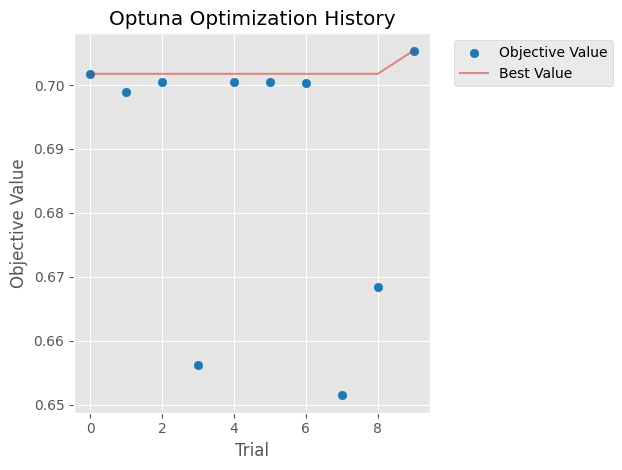

In [4]:
from optuna.visualization.matplotlib import plot_optimization_history

plot_optimization_history(study)
plt.title('Optuna Optimization History')
plt.tight_layout()
plt.show()

## Model Training

Training the final CreditScorecardModel using the best hyperparameters found by Optuna.

In [5]:
model = CreditScorecardModel(random_state=42)
model.model.set_params(**study.best_params)

logger.info('Fitting final pipeline model...')
model.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model.model, X_train_woe, y_train, cv=cv, scoring='roc_auc')
print(f'5-Fold CV AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

2026-05-23 12:02:32,922 - __main__ - INFO - Fitting final pipeline model...
2026-05-23 12:02:32,923 - src.models.scorecard - INFO - Fitting CreditScorecardModel pipeline...
2026-05-23 12:02:32,925 - src.features.woe_iv - INFO - Fitting WoEBinner...
2026-05-23 12:02:33,160 - src.features.woe_iv - INFO - WoEBinner fitting complete.
2026-05-23 12:02:36,300 - src.models.scorecard - INFO - CreditScorecardModel fitting complete.


5-Fold CV AUC: 0.7054 ± 0.0034


## Evaluation

Evaluating the scorecard on the holdout test set.

In [6]:
logger.info('Generating predictions on test set...')
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_score = model.predict_score(X_test)

2026-05-23 12:02:42,155 - __main__ - INFO - Generating predictions on test set...


In [7]:
metrics_dict = evaluate_scorecard(y_test.values, y_pred_proba)

metrics_df = pd.DataFrame([
    {'Metric': k, 'Value': v}
    for k, v in metrics_dict.items()
    if not isinstance(v, (dict, list))
])
display(metrics_df)

,Metric,Value
0,auc_roc,0.708874
1,gini,0.417748
2,ks_statistic,0.304297
3,ks_threshold,0.527832
4,brier_score,0.223064
5,log_loss,0.633692
6,optimal_threshold,0.527832
7,accuracy_ratio,0.417748


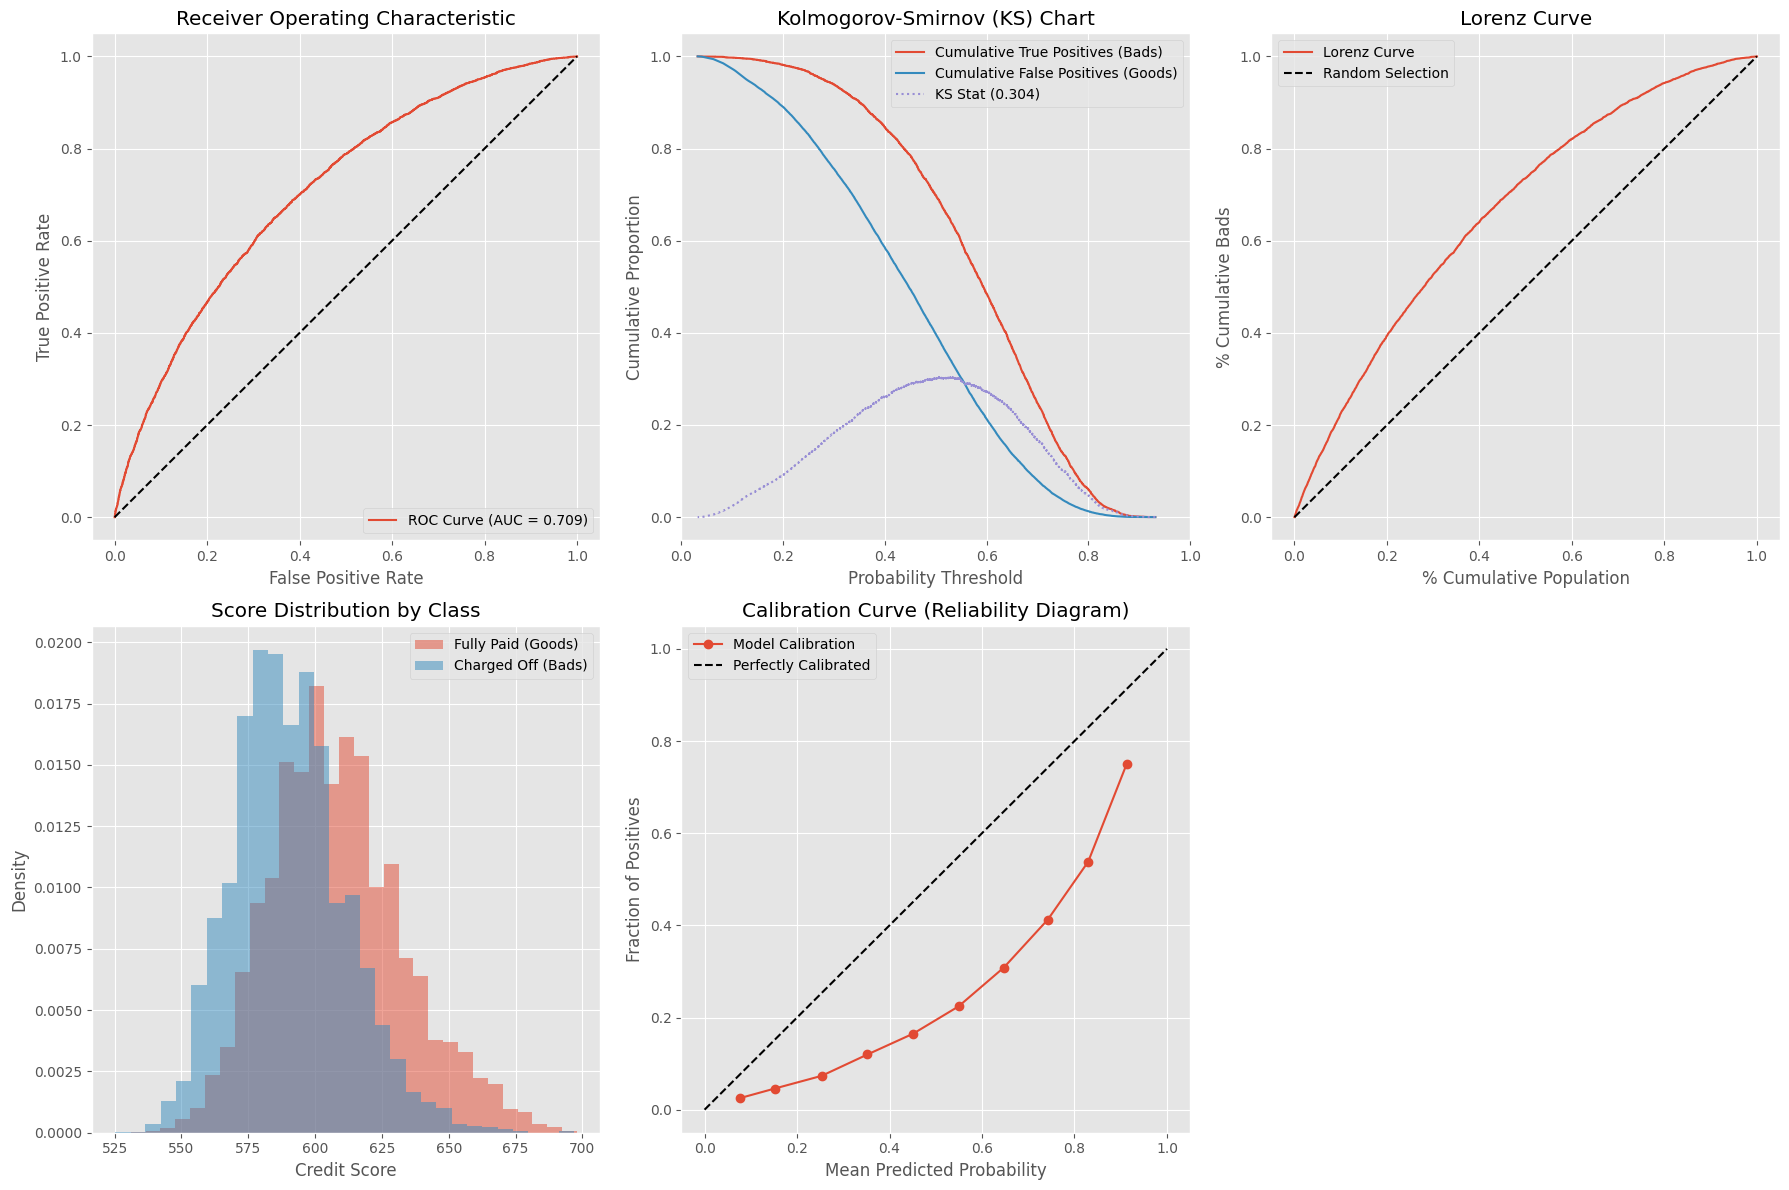

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_roc_curve(y_test.values, y_pred_proba, ax=axes[0, 0])
plot_ks_chart(y_test.values, y_pred_proba, ax=axes[0, 1])
plot_lorenz_curve(y_test.values, y_pred_proba, ax=axes[0, 2])
plot_score_distribution(y_pred_score, y_test.values, ax=axes[1, 0])
plot_calibration_curve(y_test.values, y_pred_proba, ax=axes[1, 1])

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

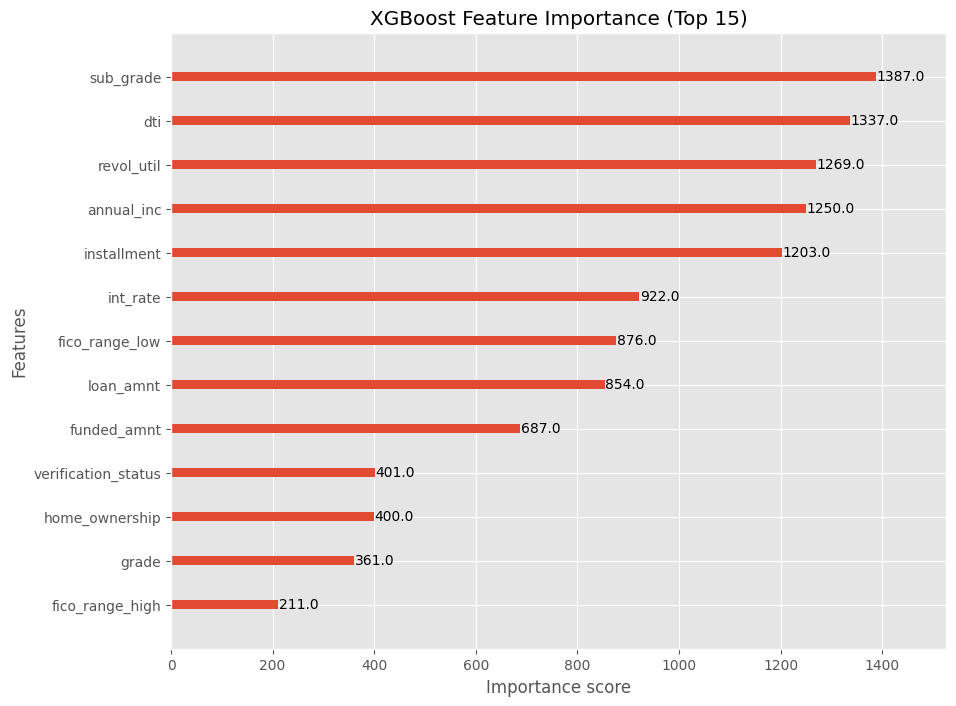

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(model.model, ax=ax, max_num_features=15, title='XGBoost Feature Importance (Top 15)')
plt.show()

## Artifact Saving

Saving the fully trained CreditScorecardModel (which includes the fitted WoEBinner) to disk.

In [10]:
import os
artifacts_dir = '../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

model_path = os.path.join(artifacts_dir, 'xgboost_scorecard_v1.joblib')
model.save(model_path)
logger.info(f'Model saved to {model_path}')

2026-05-23 12:02:44,002 - src.models.scorecard - INFO - Model successfully saved to ../artifacts/xgboost_scorecard_v1.joblib
2026-05-23 12:02:44,003 - __main__ - INFO - Model saved to ../artifacts/xgboost_scorecard_v1.joblib
